In [1]:
Output = '/Users/alexis/Library/CloudStorage/OneDrive-UniversityofNorthCarolinaatChapelHill/CEMALB_DataAnalysisPM/Projects/P1014. Nanoparticles Respiratory Tract/P1014.3. Analyses/P1014.3.2. Volcano Plots/Output'
cur_date = '021626'

library(readxl)
library(openxlsx)
library(writexl)
library(tidyverse)
library(ggrepel)
library(ggsci)

# reading in files
two_group_df = data.frame(read_excel("Input/Two_Group_Results_021626.xlsx")) 
three_group_df = data.frame(read_excel("Input/Three_Group_Results_021626.xlsx")) 

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
head(two_group_df)
head(three_group_df)

,ELISA_ID,UniProt_ID,Protein_Name,Comparison,logFC,P.Value,P.Adj
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
1,nEL04021,O00300,TNFRSF11B,NP1 vs. NP1-Rhodamine B 0.05mg/mL,0.18715386,6.180248e-10,1.730469e-07
2,nEL03731,P10909,CLU,NP1 vs. NP1-Rhodamine B 0.05mg/mL,0.11914174,4.457688e-06,6.240764e-04
3,nEL03981,P10646,TFPI,NP1 vs. NP1-Rhodamine B 0.05mg/mL,-0.06326879,7.870113e-05,7.132558e-03
4,nEL00061,P10147,CCL3,NP1 vs. NP1-Rhodamine B 0.05mg/mL,-0.07326130,1.018937e-04,7.132558e-03
5,nEL00351,P42830,CXCL5,NP1 vs. NP1-Rhodamine B 0.05mg/mL,0.06446898,1.037832e-03,5.723293e-02
6,nEL00501,P09919,G-CSF,NP1 vs. NP1-Rhodamine B 0.05mg/mL,0.03905541,1.226420e-03,5.723293e-02


,ELISA_ID,UniProt_ID,Protein_Name,Comparison,Exposure,logFC,P.Value,P.Adj
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
1,nEL03731,P10909,CLU,Control vs. NP1 0.05mg/mL vs. NP1 0.1mg/mL,Low_vs_Control,-0.34776426,1.976759e-12,5.534927e-10
2,nEL04021,O00300,TNFRSF11B,Control vs. NP1 0.05mg/mL vs. NP1 0.1mg/mL,Low_vs_Control,-0.31271390,3.511780e-10,4.916492e-08
3,nEL00061,P10147,CCL3,Control vs. NP1 0.05mg/mL vs. NP1 0.1mg/mL,Low_vs_Control,0.13673909,2.856369e-08,2.665944e-06
4,nEL08971,Q99538,LGMN,Control vs. NP1 0.05mg/mL vs. NP1 0.1mg/mL,Low_vs_Control,-0.07194295,5.691948e-05,3.984363e-03
5,nEL03101,Q15389,Angiopoietin-1,Control vs. NP1 0.05mg/mL vs. NP1 0.1mg/mL,Low_vs_Control,-0.07316786,7.386339e-05,4.136350e-03
6,nEL01981,Q99988,GDF-15 (MIC-1),Control vs. NP1 0.05mg/mL vs. NP1 0.1mg/mL,Low_vs_Control,0.07221394,1.030797e-04,4.810385e-03


Creating a volcano plot to differences in protein expression after exposure to phthalates and nylon.

In [4]:
get_significance = function(df){
    # adding a col to denote whether a protein had a significant p value, log FC, or both
    
    # add a column of NAs
    df$diffexpressed <- "No Significance"
    
    # if p adj is significant only
    df$diffexpressed[df$P.Adj < 0.05] <- "P Adjust Only"
    
    # if logFoldChange > log(1.5) and p adj < 0.01, set as "significant" 
    df$diffexpressed[abs(df$logFC) > log2(1.5) & df$P.Adj < 0.05] <- "P Adjust and log Fold Change"
    
    # making into a factor
    df$diffexpressed = factor(df$diffexpressed, levels = c("No Significance", "P Adjust Only", 
                                                                           "P Adjust and log Fold Change"))

    return(df)
}

# calling fn
two_sig_protein_df = get_significance(two_group_df)
three_sig_protein_df = get_significance(three_group_df)

head(two_sig_protein_df)

,ELISA_ID,UniProt_ID,Protein_Name,Comparison,logFC,P.Value,P.Adj,diffexpressed
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<fct>
1,nEL04021,O00300,TNFRSF11B,NP1 vs. NP1-Rhodamine B 0.05mg/mL,0.18715386,6.180248e-10,1.730469e-07,P Adjust Only
2,nEL03731,P10909,CLU,NP1 vs. NP1-Rhodamine B 0.05mg/mL,0.11914174,4.457688e-06,6.240764e-04,P Adjust Only
3,nEL03981,P10646,TFPI,NP1 vs. NP1-Rhodamine B 0.05mg/mL,-0.06326879,7.870113e-05,7.132558e-03,P Adjust Only
4,nEL00061,P10147,CCL3,NP1 vs. NP1-Rhodamine B 0.05mg/mL,-0.07326130,1.018937e-04,7.132558e-03,P Adjust Only
5,nEL00351,P42830,CXCL5,NP1 vs. NP1-Rhodamine B 0.05mg/mL,0.06446898,1.037832e-03,5.723293e-02,No Significance
6,nEL00501,P09919,G-CSF,NP1 vs. NP1-Rhodamine B 0.05mg/mL,0.03905541,1.226420e-03,5.723293e-02,No Significance


In [5]:
# cleaning names
np1_df = three_sig_protein_df %>%
    filter(Comparison == 'Control vs. NP1 0.05mg/mL vs. NP1 0.1mg/mL') %>%
    mutate(Exposure = ifelse(Exposure == "Low_vs_Control", "Control vs. NP1 0.05mg/mL",
                                        ifelse(Exposure == "High_vs_Control", "Control vs. NP1 0.1mg/mL",
                                        ifelse(Exposure == "High_vs_Low", "NP1 0.05mg/mL vs. NP1 0.1mg/mL", 
                                               Exposure))))
np1r_df = three_sig_protein_df %>%
    filter(Comparison == 'Control vs. NP1-Rhodamine B 0.05mg/mL vs. NP1-Rhodamine B 0.1mg/mL') %>%
    mutate(Exposure = ifelse(Exposure == "Low_vs_Control", "Control vs. NP1-Rhodamine B 0.05mg/mL",
                                        ifelse(Exposure == "High_vs_Control", "Control vs. NP1-Rhodamine B 0.1mg/mL",
                                        ifelse(Exposure == "High_vs_Low", "NP1-Rhodamine B 0.05mg/mL vs.\nNP1-Rhodamine B 0.1mg/mL", 
                                               Exposure))))

Used a limma linear model to perform the two group comparisons below:
- NP1 0.05mg/mL vs. NP1 Rhodamine B 0.05mg/mL
- NP1 0.1mg/mL vs. NP1 Rhodamine B 0.1mg/mL
- NP1 0.1mg/mL vs. NP2 0.1mg/mL

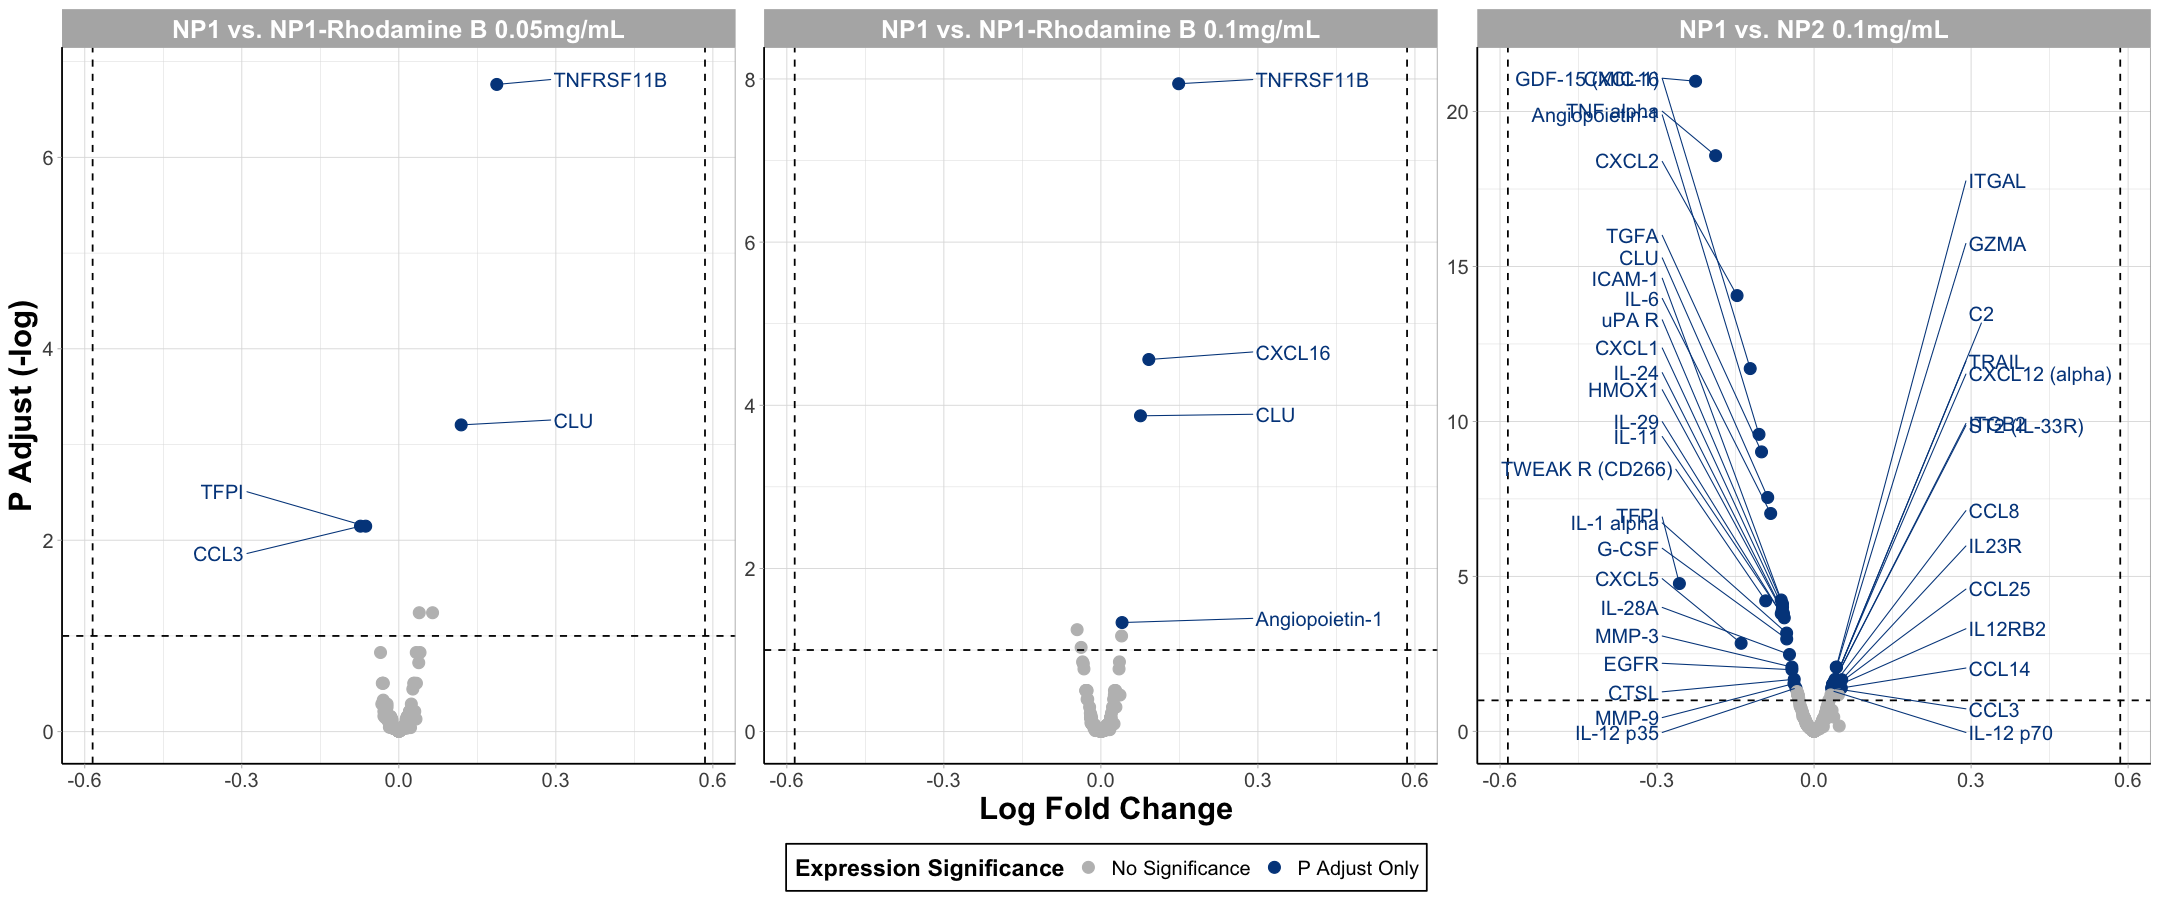

In [6]:
options(repr.plot.width=18, repr.plot.height=7.5) #changing size

lancet_palette = pal_lancet()(2)

ggplot() + 
  geom_point(data = two_sig_protein_df, aes(x = logFC, y = -log10(P.Adj), color = diffexpressed), size = 3) + 

  # P Value line
  geom_hline(yintercept = -log10(0.1), linetype = "dashed") + 
  # FC Line
  geom_vline(xintercept = log2(1.5), linetype = "dashed") +
  geom_vline(xintercept = -log2(1.5), linetype = "dashed") +

  # changing x limits of what is visible in the plot
 #    xlim(-5, 8) + 
 #    ylim(0, 2.1) + 

  geom_text_repel(data = two_sig_protein_df %>%
                  filter(logFC > 0, P.Adj < 0.05),
                  aes(x = logFC, y = -log10(P.Adj), label = Protein_Name, color = diffexpressed),
                  hjust = 'right', direction = 'y', nudge_y = 0.05, nudge_x = 0.03, xlim = c(0.25, NA), 
                  segment.size = 0.3, box.padding = 1, max.overlaps = Inf, size = 4.2, show.legend = FALSE) + 

 geom_text_repel(data = two_sig_protein_df %>%
                  filter(logFC < 0, P.Adj < 0.05), 
                  aes(x = logFC, y = -log10(P.Adj), label = Protein_Name, color = diffexpressed), 
                  hjust = 'left', direction = 'y', nudge_y = 0.05, nudge_x = -0.03, xlim = c(NA, -0.25), 
                 segment.size = 0.3, box.padding = 1, max.overlaps = Inf, size = 4.2, show.legend = FALSE) + 

  facet_wrap(~Comparison, scales = 'free') + 

  theme_light() + 
  theme(axis.line = element_line(colour = "black"), #making x and y axes black
        axis.text = element_text(size = 12), #changing size of x axis labels
        axis.title = element_text(face = "bold", size = rel(1.7)), #changes axis titles
        legend.title = element_text(face = 'bold', size = 14), #changes legend title
        legend.text = element_text(size = 12), #changes legend text
        legend.position = "bottom", # changing legend position
        legend.background = element_rect(colour = 'black', fill = 'white', linetype = 'solid'),
        strip.text.x = element_text(size = 15, face = "bold"), #changes size of facet x axis 
        strip.text.y = element_text(size = 15, face = "bold")) + #changes size of facet y axis 
  labs(x = "Log Fold Change", y = 'P Adjust (-log)') +

  scale_color_manual(name = "Expression Significance",
                      values = c("gray", lancet_palette[1]))

Used an ANOVA to compare across groups below:

- Control vs. NP1 0.05mg/mL vs. NP1 0.1mg/mL
- Control vs. NP1 Rhodamine B 0.05mg/mL vs. NP1 Rhodamine B 0.1mg/mL

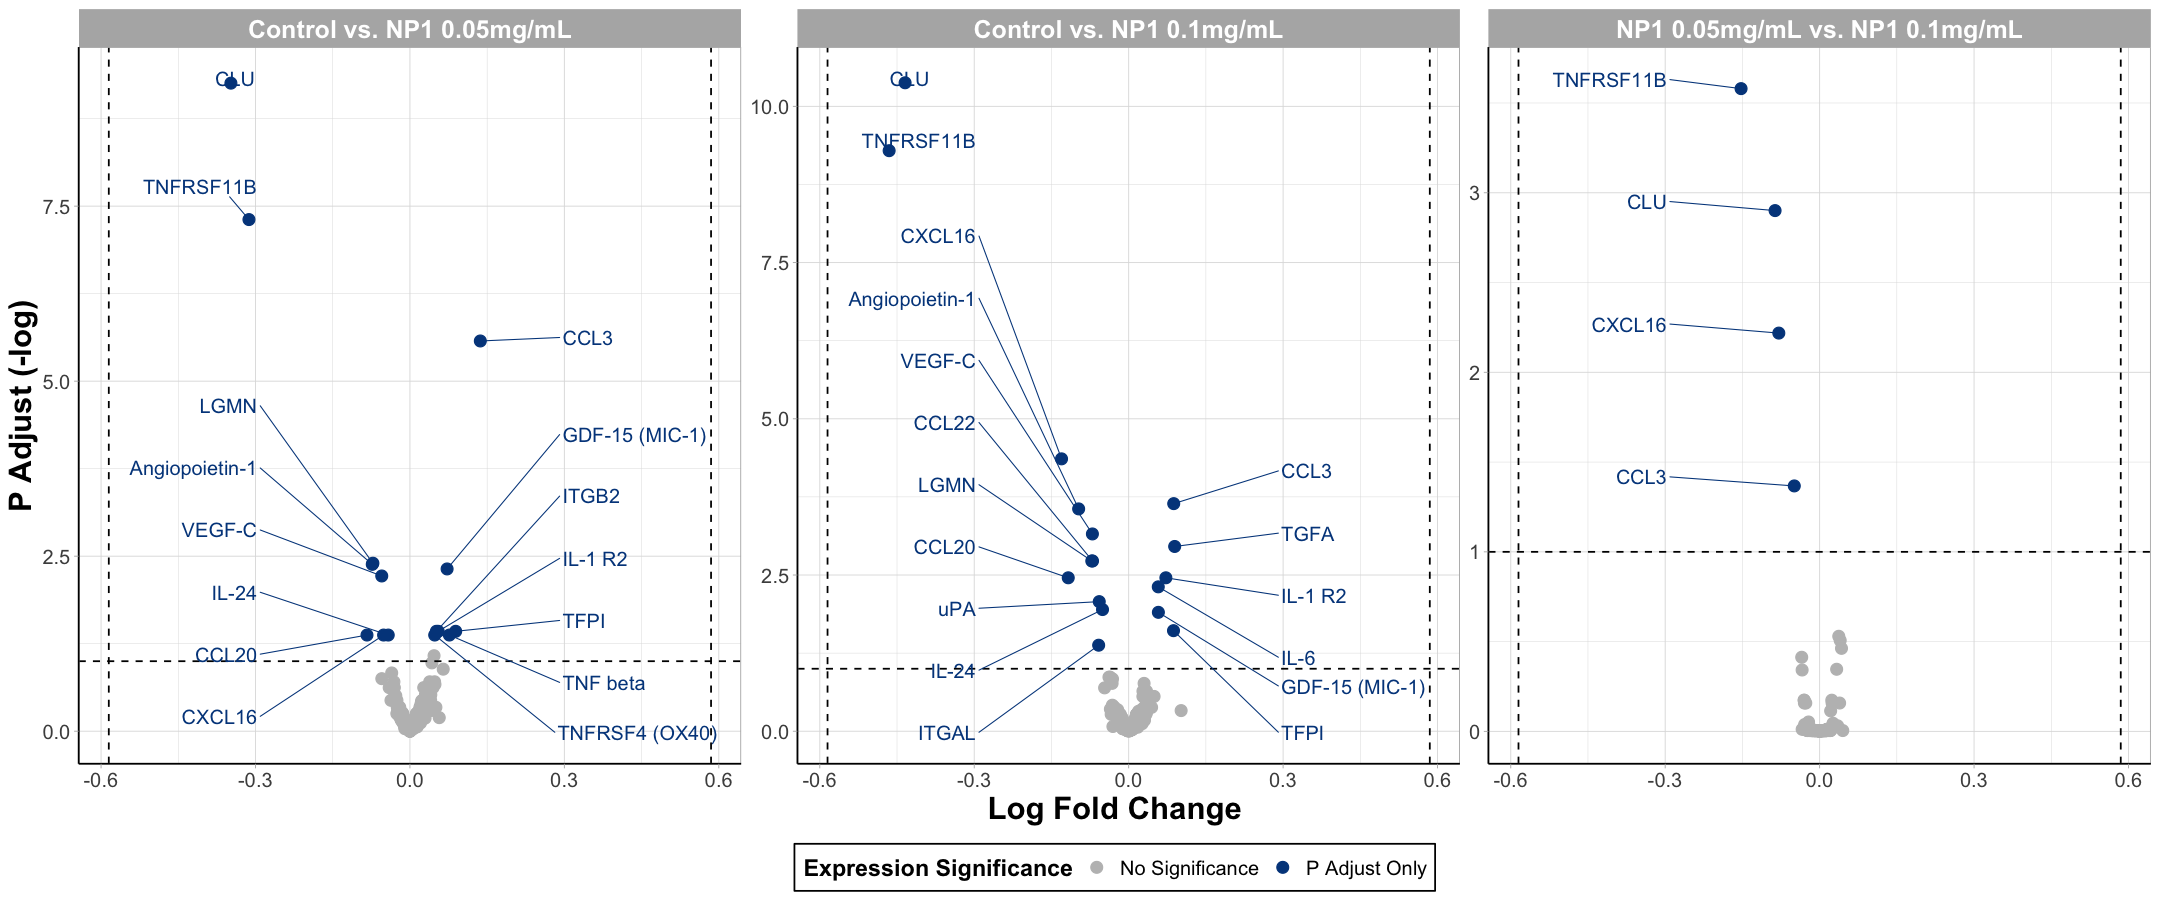

In [7]:
ggplot() + 
  geom_point(data = np1_df, aes(x = logFC, y = -log10(P.Adj), color = diffexpressed), size = 3) + 

  # P Value line
  geom_hline(yintercept = -log10(0.1), linetype = "dashed") + 
  # FC Line
  geom_vline(xintercept = log2(1.5), linetype = "dashed") +
  geom_vline(xintercept = -log2(1.5), linetype = "dashed") +

  # changing x limits of what is visible in the plot
 #    xlim(-5, 8) + 
 #    ylim(0, 2.1) + 

  geom_text_repel(data = np1_df %>%
                  filter(logFC > 0, P.Adj < 0.05),
                  aes(x = logFC, y = -log10(P.Adj), label = Protein_Name, color = diffexpressed),
                  hjust = 'right', direction = 'y', nudge_y = 0.05, nudge_x = 0.03, xlim = c(0.25, NA), 
                  segment.size = 0.3, box.padding = 1, max.overlaps = Inf, size = 4.2, show.legend = FALSE) + 

 geom_text_repel(data = np1_df %>%
                  filter(logFC < 0, P.Adj < 0.05), 
                  aes(x = logFC, y = -log10(P.Adj), label = Protein_Name, color = diffexpressed), 
                  hjust = 'left', direction = 'y', nudge_y = 0.05, nudge_x = -0.03, xlim = c(NA, -0.25), 
                 segment.size = 0.3, box.padding = 1, max.overlaps = Inf, size = 4.2, show.legend = FALSE) + 

  facet_wrap(~Exposure, scales = 'free') + 

  theme_light() + 
  theme(axis.line = element_line(colour = "black"), #making x and y axes black
        axis.text = element_text(size = 12), #changing size of x axis labels
        axis.title = element_text(face = "bold", size = rel(1.7)), #changes axis titles
        legend.title = element_text(face = 'bold', size = 14), #changes legend title
        legend.text = element_text(size = 12), #changes legend text
        legend.position = "bottom", # changing legend position
        legend.background = element_rect(colour = 'black', fill = 'white', linetype = 'solid'),
        strip.text.x = element_text(size = 15, face = "bold"), #changes size of facet x axis 
        strip.text.y = element_text(size = 15, face = "bold")) + #changes size of facet y axis 
  labs(x = "Log Fold Change", y = 'P Adjust (-log)') +

  scale_color_manual(name = "Expression Significance",
                      values = c("gray", lancet_palette[1]))

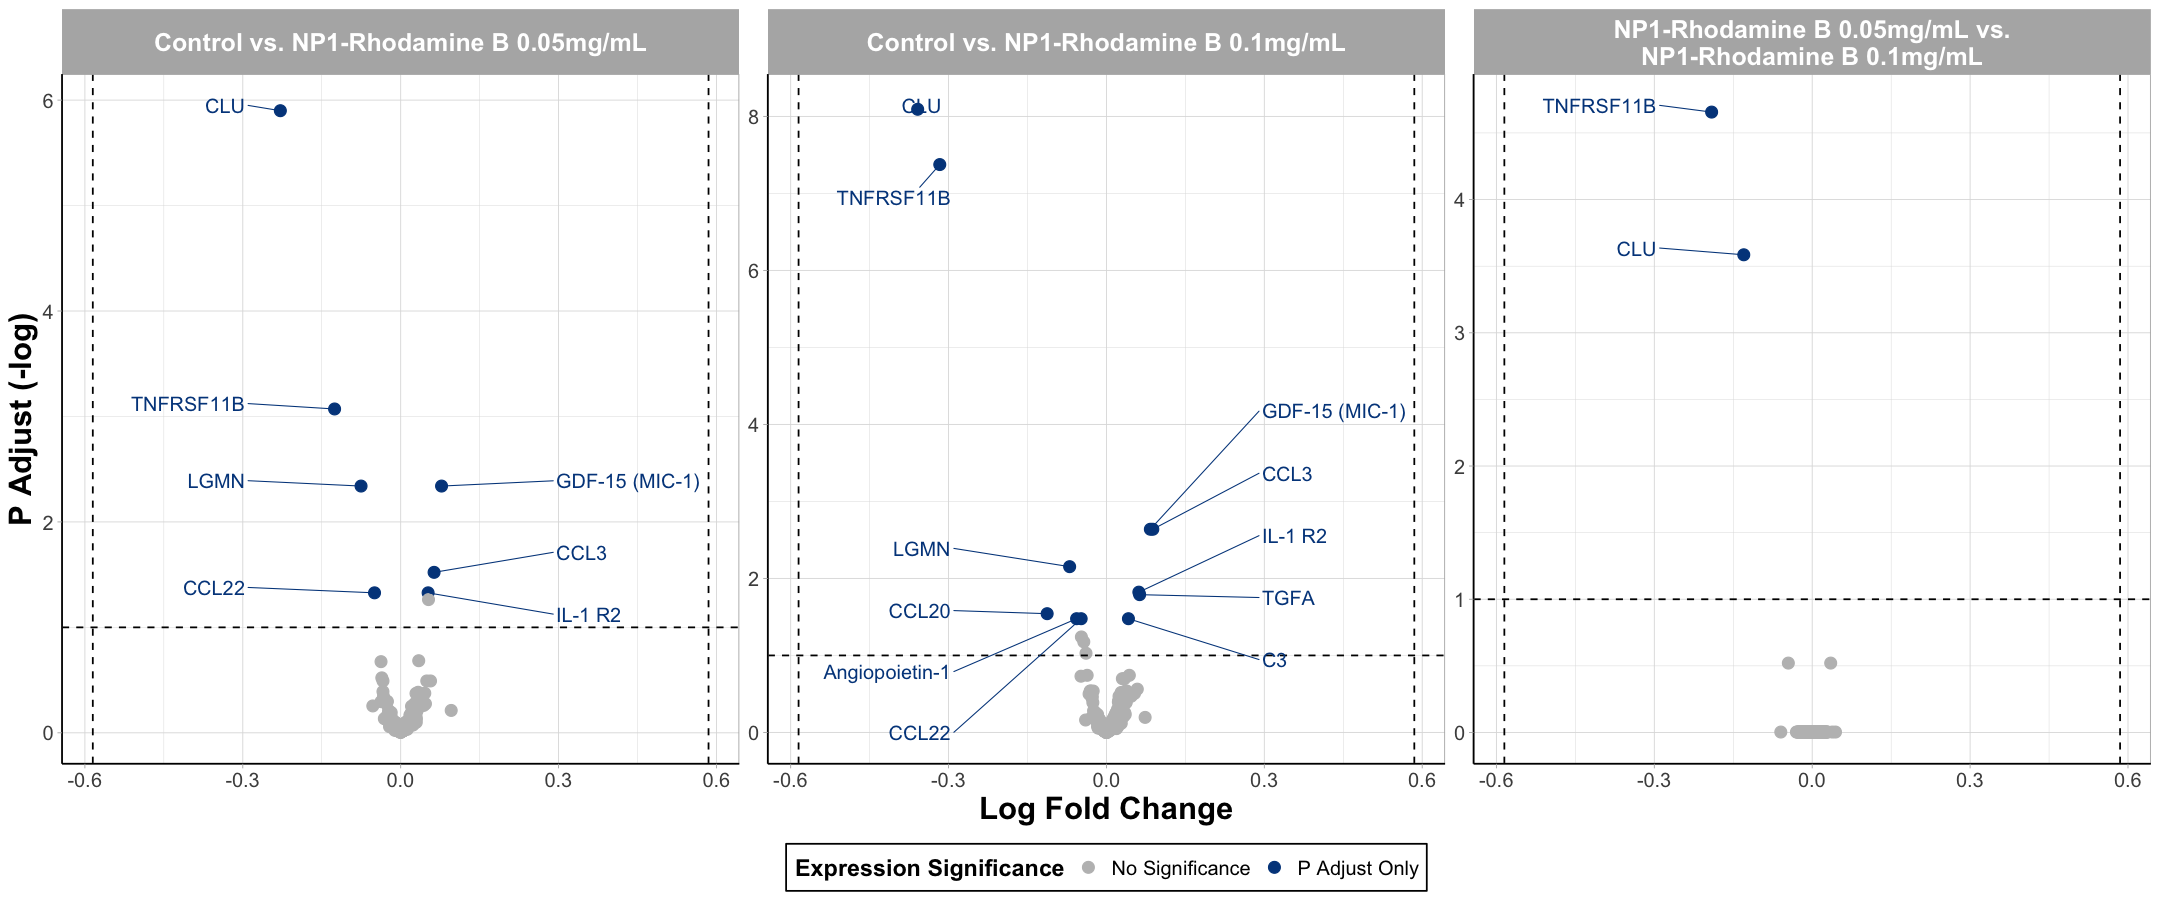

In [8]:
ggplot() + 
  geom_point(data = np1r_df, aes(x = logFC, y = -log10(P.Adj), color = diffexpressed), size = 3) + 

  # P Value line
  geom_hline(yintercept = -log10(0.1), linetype = "dashed") + 
  # FC Line
  geom_vline(xintercept = log2(1.5), linetype = "dashed") +
  geom_vline(xintercept = -log2(1.5), linetype = "dashed") +

  # changing x limits of what is visible in the plot
 #    xlim(-5, 8) + 
 #    ylim(0, 2.1) + 

  geom_text_repel(data = np1r_df %>%
                  filter(logFC > 0, P.Adj < 0.05),
                  aes(x = logFC, y = -log10(P.Adj), label = Protein_Name, color = diffexpressed),
                  hjust = 'right', direction = 'y', nudge_y = 0.05, nudge_x = 0.03, xlim = c(0.25, NA), 
                  segment.size = 0.3, box.padding = 1, max.overlaps = Inf, size = 4.2, show.legend = FALSE) + 

 geom_text_repel(data = np1r_df %>%
                  filter(logFC < 0, P.Adj < 0.05), 
                  aes(x = logFC, y = -log10(P.Adj), label = Protein_Name, color = diffexpressed), 
                  hjust = 'left', direction = 'y', nudge_y = 0.05, nudge_x = -0.03, xlim = c(NA, -0.25), 
                 segment.size = 0.3, box.padding = 1, max.overlaps = Inf, size = 4.2, show.legend = FALSE) + 

  facet_wrap(~Exposure, scales = 'free') + 

  theme_light() + 
  theme(axis.line = element_line(colour = "black"), #making x and y axes black
        axis.text = element_text(size = 12), #changing size of x axis labels
        axis.title = element_text(face = "bold", size = rel(1.7)), #changes axis titles
        legend.title = element_text(face = 'bold', size = 14), #changes legend title
        legend.text = element_text(size = 12), #changes legend text
        legend.position = "bottom", # changing legend position
        legend.background = element_rect(colour = 'black', fill = 'white', linetype = 'solid'),
        strip.text.x = element_text(size = 15, face = "bold"), #changes size of facet x axis 
        strip.text.y = element_text(size = 15, face = "bold")) + #changes size of facet y axis 
  labs(x = "Log Fold Change", y = 'P Adjust (-log)') +

  scale_color_manual(name = "Expression Significance",
                      values = c("gray", lancet_palette[1]))